# CNN for Mammography Classification — DDSM

**Project:** Deep Learning for Breast Cancer Detection  
**Dataset:** DDSM Mammography (`skooch/ddsm-mammography`) — TFRecords  
**Task:** Binary classification — Negative vs Positive (abnormal)  
**Framework:** TensorFlow / Keras — Kaggle

---

## Overview

This notebook follows a systematic experimental progression, starting from a simple baseline CNN and incrementally adding techniques to improve generalisation. Each experiment introduces one targeted change so that the effect of each intervention can be clearly attributed.

Key design decisions applied throughout:
- **BatchNormalization** after every Conv2D layer — stabilises gradients and accelerates convergence
- **Lower learning rate** (1e-4) — prevents overshooting on this fine-grained classification task
- **Class weights** — corrects for negative/positive imbalance (~86% negative, ~14% positive)

| Experiment | Change | Twist |
|---|---|---|
| Exp 0 | Simple baseline CNN + BN | — |
| Exp 1 | Dropout + SpatialDropout2D + BN | SpatialDropout2D in conv layers |
| Exp 2 | Data augmentation + GaussianNoise + BN | GaussianNoise for scanner variability |
| Exp 3 | Larger network (3 conv blocks) + BN | Skip connection from Block 3 |
| Exp 4 | Larger FC layer (48 neurons) + BN | Dual parallel dense paths |
| Exp 5 | Learning rate decay + BN | Cosine annealing schedule |
| Exp 6 | Deeper network (4 conv blocks) + BN | Pyramid pooling at 2 scales |
| Exp 7 | L2 regularisation on all layers + BN | Applied to conv + dense layers |

## Code Block 1 — Setup and Data Pipeline

Data streams directly from Kaggle input via `tf.data` — images are never loaded
into RAM all at once. Each batch is read, preprocessed (CLAHE + denoising +
resize + normalise + augment), and fed to the model on the fly.

- Input shape: **(224, 224, 3)** — resized from 299x299, grayscale replicated to RGB
- Labels: **0 = Negative (normal)**, **1 = Positive (abnormal)**
- Training uses files 0–3; file 4 is split into validation and test sets

> **Dataset:** Add `skooch/ddsm-mammography` via the Kaggle **Add Data** button before running.

In [10]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

# ── Kaggle paths ──────────────────────────────────────────────────────────────
# To this:
DATA_DIR  = '/kaggle/input/datasets/skooch/ddsm-mammography'
SAVE_PATH = '/kaggle/working'
# ─────────────────────────────────────────────────────────────────────────────

TARGET_SIZE     = (224, 224)
BATCH_SIZE      = 32
CLAHE_PROCESSOR = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

FEATURE_DICT = {
    'label':        tf.io.FixedLenFeature([], tf.int64),
    'label_normal': tf.io.FixedLenFeature([], tf.int64),
    'image':        tf.io.FixedLenFeature([], tf.string),
}

def parse(serialized_example):
    features = tf.io.parse_single_example(serialized_example, FEATURE_DICT)
    label    = features['label_normal']
    image    = tf.io.decode_raw(features['image'], tf.uint8)
    image    = tf.reshape(image, [299, 299, 1])

    def enhance_and_resize(img):
        img = img[:, :, 0]
        img = cv2.GaussianBlur(img, ksize=(3, 3), sigmaX=1)
        img = CLAHE_PROCESSOR.apply(img)
        img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
        img = cv2.merge([img, img, img])
        img = img.astype(np.float32) / 255.0
        return img

    image = tf.numpy_function(enhance_and_resize, [image], tf.float32)
    image.set_shape([224, 224, 3])
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Verify dataset files are present
print('Checking dataset files...')
for i in range(5):
    p = os.path.join(DATA_DIR, f'training10_{i}', f'training10_{i}.tfrecords')
    exists = os.path.exists(p)
    print(f'  training10_{i}.tfrecords : {"FOUND" if exists else "MISSING — check dataset is added"}')

train_files = [
    os.path.join(DATA_DIR, f'training10_{i}', f'training10_{i}.tfrecords')
    for i in range(4)
]
file_4 = os.path.join(DATA_DIR, 'training10_4', 'training10_4.tfrecords')

total_file4 = sum(1 for _ in tf.data.TFRecordDataset(file_4))
val_size    = total_file4 // 2

train_dataset = (
    tf.data.TFRecordDataset(train_files)
    .shuffle(2000)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.TFRecordDataset(file_4)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .take(val_size)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.TFRecordDataset(file_4)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .skip(val_size)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

class_weight_dict = {0: 1.0, 1: 6.0}

results = {}

print('\nEverything ready. Run the experiment cells now.')
print(f'Train : files 0-3  shuffled + augmented')
print(f'Val   : file 4 first half  ({val_size:,} images)')
print(f'Test  : file 4 second half ({total_file4 - val_size:,} images)')
print(f'Class weights: {class_weight_dict}')
print(f'Saving models to: {SAVE_PATH}')

Checking dataset files...
  training10_0.tfrecords : FOUND
  training10_1.tfrecords : FOUND
  training10_2.tfrecords : FOUND
  training10_3.tfrecords : FOUND
  training10_4.tfrecords : FOUND

Everything ready. Run the experiment cells now.
Train : files 0-3  shuffled + augmented
Val   : file 4 first half  (5,588 images)
Test  : file 4 second half (5,589 images)
Class weights: {0: 1.0, 1: 6.0}
Saving models to: /kaggle/working


## Code Block 2 — Reusable Evaluation Function

A single evaluation function is defined once and called after every experiment.
It produces three plots — confusion matrix, ROC curve, and precision-recall curve —
and saves both evaluation and history plots to `/kaggle/working`.
Results accumulate in a dictionary for final comparison.

In [11]:
def evaluate_experiment(exp_name, model_path, history, test_dataset,
                        save_path, results):
    print(f'\nLoading {model_path}...')
    model = tf.keras.models.load_model(model_path)

    # Collect all predictions and true labels from the test dataset
    y_pred_probs, y_true = [], []
    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0).flatten()
        y_pred_probs.extend(preds)
        y_true.extend(labels.numpy())

    y_pred_probs = np.array(y_pred_probs)
    y_true       = np.array(y_true)
    y_pred       = (y_pred_probs >= 0.5).astype(int)

    print(f'True:      {np.unique(y_true, return_counts=True)}')
    print(f'Predicted: {np.unique(y_pred, return_counts=True)}')
    print('\n' + '='*55)
    print(f'{exp_name.upper()} -- CLASSIFICATION REPORT')
    print('='*55)
    print(classification_report(y_true, y_pred,
                                 target_names=['Negative', 'Positive']))

    cm             = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr, tpr, _    = roc_curve(y_true, y_pred_probs)
    roc_auc        = auc(fpr, tpr)
    accuracy       = (tp + tn) / len(y_true)
    sensitivity    = tp / (tp + fn)
    specificity    = tn / (tn + fp)
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
    pr_auc         = auc(recall_vals, precision_vals)

    # Evaluation plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{exp_name} -- Evaluation', fontsize=14, fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[2].plot(recall_vals, precision_vals, color='darkorange', lw=2,
                 label=f'PR-AUC = {pr_auc:.3f}')
    axes[2].axhline(y=sum(y_true)/len(y_true), color='k',
                    linestyle='--', lw=1, label='Baseline')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    fname = exp_name.lower().replace(' ', '_').replace('-', '').replace('+', '')
    plt.savefig(f'{save_path}/{fname}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Evaluation plot saved')

    # History plots
    if history is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{exp_name} -- Training History', fontsize=14, fontweight='bold')
        axes[0].plot(history.history['loss'],     label='Train')
        axes[0].plot(history.history['val_loss'], label='Val')
        axes[0].set_title('Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        axes[1].plot(history.history['auc'],     label='Train')
        axes[1].plot(history.history['val_auc'], label='Val')
        axes[1].set_title('AUC')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{save_path}/{fname}_history.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('History plot saved')

    print(f'\n{"="*55}')
    print(f'{exp_name.upper()} SUMMARY')
    print(f'{"="*55}')
    print(f'Accuracy:                {accuracy:.3f}')
    print(f'ROC-AUC:                 {roc_auc:.3f}')
    print(f'Sensitivity (Positive):  {sensitivity:.3f}')
    print(f'Specificity (Negative):  {specificity:.3f}')

    results[exp_name] = {
        'accuracy':    round(accuracy, 3),
        'roc_auc':     round(roc_auc, 3),
        'sensitivity': round(sensitivity, 3),
        'specificity': round(specificity, 3)
    }

    print('\nRESULTS TRACKER')
    print('='*55)
    for exp, m in results.items():
        print(f"{exp}: Acc={m['accuracy']} | AUC={m['roc_auc']} | "
              f"Sens={m['sensitivity']} | Spec={m['specificity']}")

    return results

results = {}
print('evaluate_experiment() defined.')

evaluate_experiment() defined.


## Experiment 0 — Baseline CNN

Simple baseline: two Conv2D blocks with BatchNormalization, one dense layer.
No dropout, no augmentation beyond the pipeline. Sets the performance floor.

In [12]:
model_0 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
], name='experiment_0_baseline')

model_0.summary()

model_0.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp0_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-7, verbose=1
)

history_0 = model_0.fit(
    train_dataset,
    epochs=150,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_0, f'{SAVE_PATH}/exp0_end.keras')
import gc
del model_0
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared — ready for Exp 1")
print('Experiment 0 done')

Model: "experiment_0_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     6,422,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,442,497 (24.58 MB)

 Trainable params: 6,442,241 (24.58 MB)

 Non-trainable params: 256 (1.00 KB)

...

      4/Unknown 10s 43ms/step - accuracy: 0.5299 - auc: 0.6263 - loss: 1.3871 - precision: 0.1652 - recall: 0.6746

I0000 00:00:1774165854.942755     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   1398/Unknown 134s 89ms/step - accuracy: 0.7142 - auc: 0.8617 - loss: 0.8254 - precision: 0.2998 - recall: 0.8741

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_auc improved from -inf to 0.90096, saving model to /kaggle/working/exp0_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 146s 97ms/step - accuracy: 0.7142 - auc: 0.8618 - loss: 0.8254 - precision: 0.2999 - recall: 0.8741 - val_accuracy: 0.8169 - val_auc: 0.9010 - val_loss: 0.4347 - val_precision: 0.3972 - val_recall: 0.8521 - learning_rate: 1.0000e-04
Epoch 2/150
1396/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7998 - auc: 0.8949 - loss: 0.6854 - precision: 0.3789 - recall: 0.8488
Epoch 2: val_auc did not improve from 0.90096
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 140s 100ms/step - accuracy: 0.7998 - auc: 0.8950 - loss: 0.6853 - precision: 0.3789 - recall: 0.8488 - val_accuracy: 0.8946 - val_auc: 0.8886 - val_loss: 0.2579 - val_precision: 0.6078 - val_recall: 0.4803 - learning_rate: 1.0000e-04
Epoch 3/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8167 - auc: 0.8979 - loss: 0.6676 - precision: 0.4013 - recall: 0.8302
Epoch 3: val_auc did not improve from 0.90096



Loading /kaggle/working/exp0_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([5019,  570]))

EXP 0 - BASELINE CNN -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.93      0.96      0.95      4855
    Positive       0.69      0.53      0.60       734

    accuracy                           0.91      5589
   macro avg       0.81      0.75      0.77      5589
weighted avg       0.90      0.91      0.90      5589



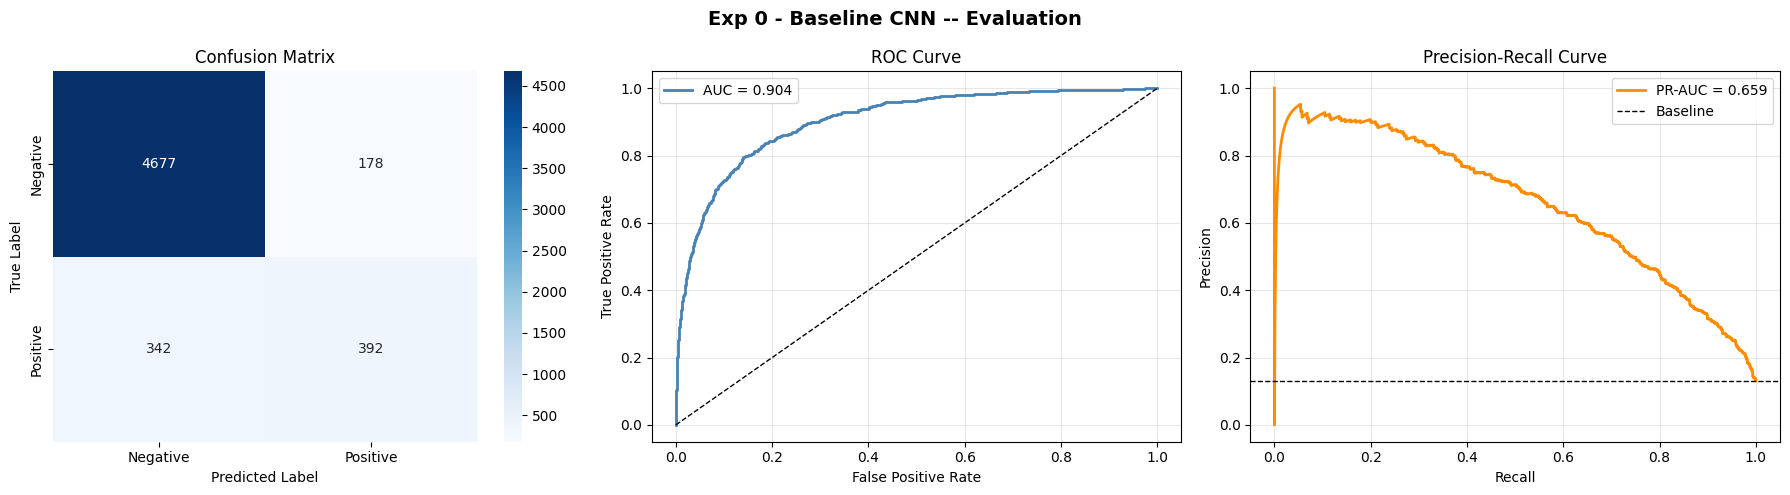

Evaluation plot saved


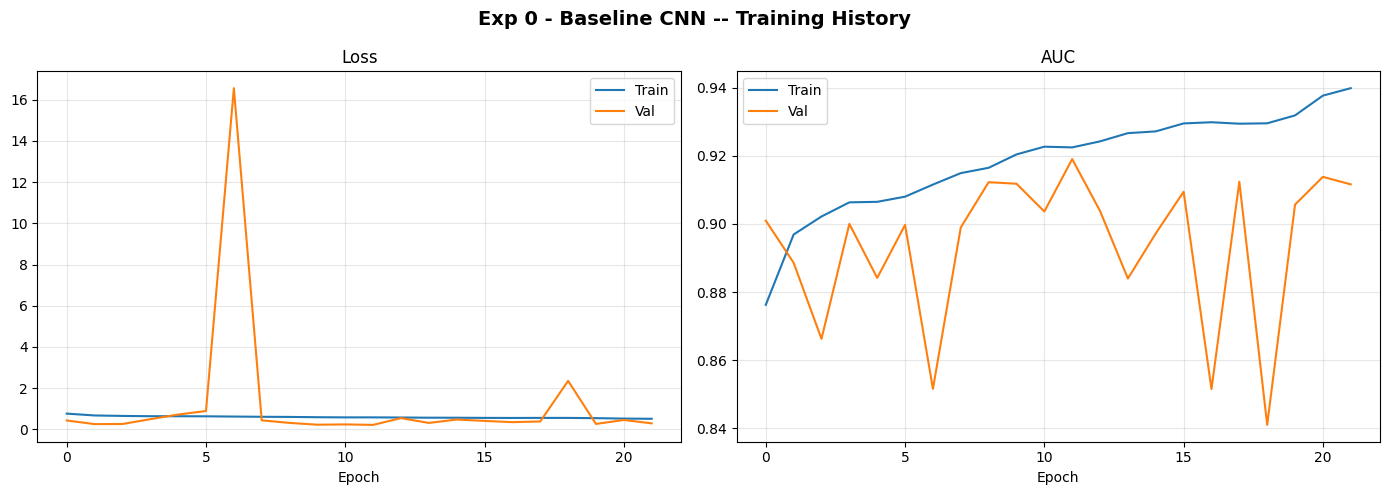

History plot saved

EXP 0 - BASELINE CNN SUMMARY
Accuracy:                0.907
ROC-AUC:                 0.904
Sensitivity (Positive):  0.534
Specificity (Negative):  0.963

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963


In [13]:
results = evaluate_experiment('Exp 0 - Baseline CNN',
    f'{SAVE_PATH}/exp0_best.keras', history_0,
    test_dataset, SAVE_PATH, results)

## Experiment 1 — Dropout + SpatialDropout2D

Adds Dropout (0.5) to the dense layer and SpatialDropout2D (0.2) after each
conv block. SpatialDropout2D drops entire feature maps rather than individual
neurons, which is more effective for spatially correlated image features.

In [14]:
model_1 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.SpatialDropout2D(0.2),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.SpatialDropout2D(0.2),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='experiment_1_dropout')

model_1.summary()

model_1.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp1_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=20,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-7, verbose=1
)

history_1 = model_1.fit(
    train_dataset,
    epochs=150,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_1, f'{SAVE_PATH}/exp1_end.keras')
import gc
del model_1
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared — ready for Exp 2")
print('Experiment 1 done')

Model: "experiment_1_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 224, 224, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 112, 112, 64)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     6,422,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,442,497 (24.58 MB)

 Trainable params: 6,442,241 (24.58 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/150
   1398/Unknown 121s 82ms/step - accuracy: 0.6480 - auc: 0.7906 - loss: 1.0227 - precision: 0.2429 - recall: 0.8023

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_auc improved from -inf to 0.86998, saving model to /kaggle/working/exp1_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 133s 90ms/step - accuracy: 0.6480 - auc: 0.7906 - loss: 1.0227 - precision: 0.2429 - recall: 0.8023 - val_accuracy: 0.6992 - val_auc: 0.8700 - val_loss: 0.5797 - val_precision: 0.2816 - val_recall: 0.8817 - learning_rate: 1.0000e-04
Epoch 2/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7347 - auc: 0.8410 - loss: 0.8570 - precision: 0.3045 - recall: 0.8102
Epoch 2: val_auc improved from 0.86998 to 0.90058, saving model to /kaggle/working/exp1_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 127s 91ms/step - accuracy: 0.7347 - auc: 0.8410 - loss: 0.8570 - precision: 0.3045 - recall: 0.8102 - val_accuracy: 0.8286 - val_auc: 0.9006 - val_loss: 0.3937 - val_precision: 0.4109 - val_recall: 0.8056 - learning_rate: 1.0000e-04
Epoch 3/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7702 - auc: 0.8578 - loss: 0.7968 - precision: 0.3351 - recall: 0


Loading /kaggle/working/exp1_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([4272, 1317]))

EXP 1 - DROPOUT + SPATIALDROPOUT2D -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.96      0.85      0.90      4855
    Positive       0.44      0.79      0.57       734

    accuracy                           0.84      5589
   macro avg       0.70      0.82      0.74      5589
weighted avg       0.90      0.84      0.86      5589



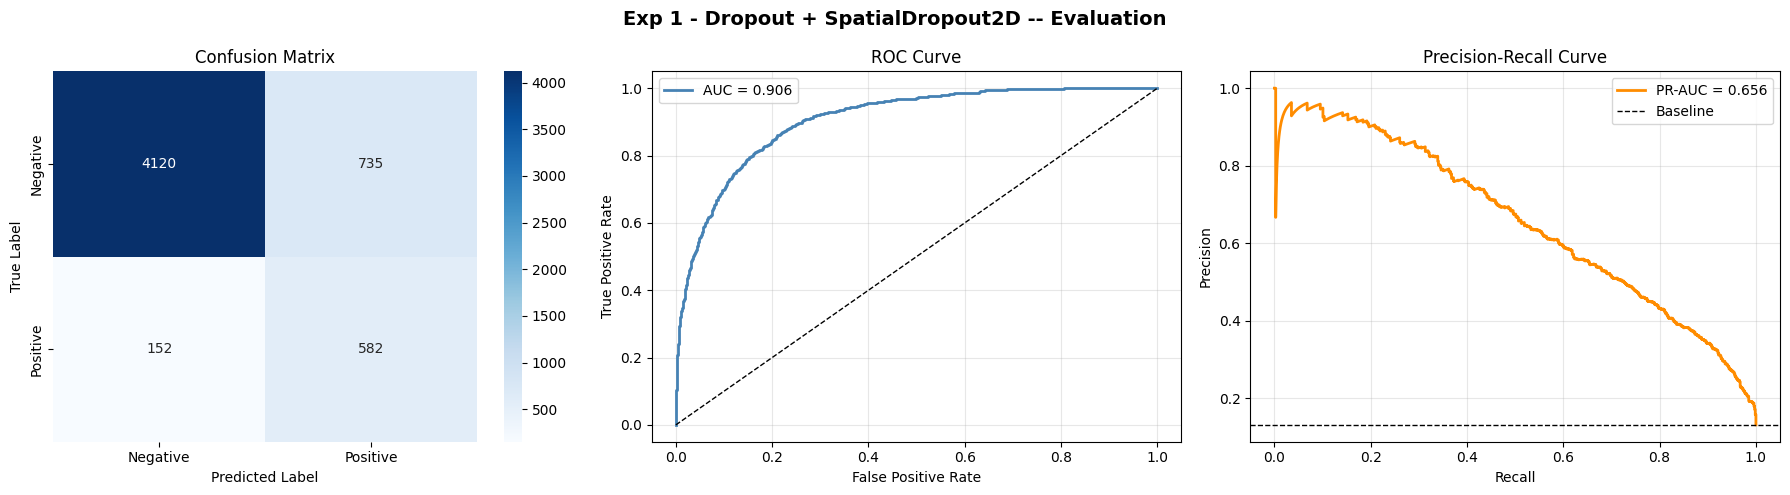

Evaluation plot saved


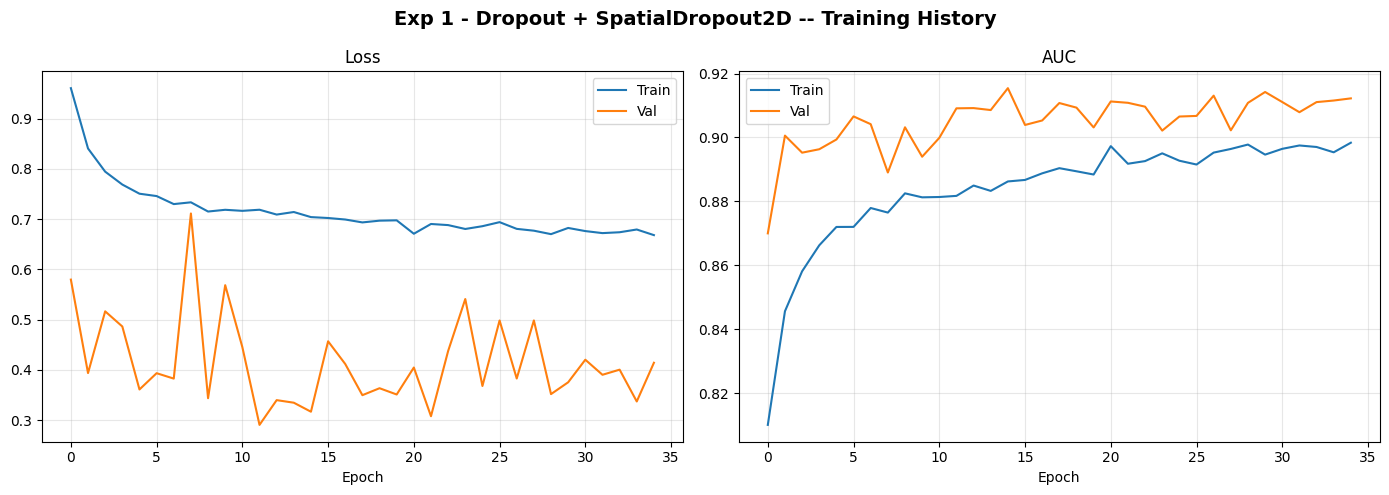

History plot saved

EXP 1 - DROPOUT + SPATIALDROPOUT2D SUMMARY
Accuracy:                0.841
ROC-AUC:                 0.906
Sensitivity (Positive):  0.793
Specificity (Negative):  0.849

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963
Exp 1 - Dropout + SpatialDropout2D: Acc=0.841 | AUC=0.906 | Sens=0.793 | Spec=0.849


In [15]:
results = evaluate_experiment('Exp 1 - Dropout + SpatialDropout2D',
    f'{SAVE_PATH}/exp1_best.keras', history_1,
    test_dataset, SAVE_PATH, results)

## Experiment 2 — Rebalanced Pipeline + GaussianNoise

From this experiment onwards the training pipeline is rebuilt to oversample the minority (positive) class using `tf.data.Dataset.sample_from_datasets`. Instead of relying solely on class weights to compensate for the ~86/14 imbalance, the model now sees a true 50/50 split of negatives and positives every batch.

**Why this helps:**
- The model trains on genuine positive examples rather than just being penalised harder for missing them
- Sensitivity (catching real cancer cases) should improve significantly
- The `.repeat()` on both streams also eliminates the "ran out of data" warning from Exp 0/1

**Changes from Exp 1:**
- New balanced `train_dataset` replacing the old imbalanced one
- Class weights reduced from `{0: 1.0, 1: 6.0}` → `{0: 1.0, 1: 1.5}` (mild nudge, not heavy penalty)
- GaussianNoise(0.02) added as first layer
- `val_dataset` and `test_dataset` left untouched — they reflect real-world distribution

In [16]:
# ── Rebuild training pipeline with balanced oversampling ─────────────────────

def is_positive(image, label):
    return tf.equal(label, 1)

def is_negative(image, label):
    return tf.equal(label, 0)

pos_dataset = (
    tf.data.TFRecordDataset(train_files)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .filter(is_positive)
    .repeat()
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
)

neg_dataset = (
    tf.data.TFRecordDataset(train_files)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .filter(is_negative)
    .repeat()
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
)

# 50/50 balance — equal sampling from positive and negative streams
train_dataset = (
    tf.data.Dataset.sample_from_datasets(
        [pos_dataset, neg_dataset],
        weights=[0.5, 0.5]
    )
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Mild class weight nudge — data is now balanced so heavy weighting is not needed
class_weight_dict = {0: 1.0, 1: 1.5}

print('Balanced pipeline ready.')
print(f'Class weights updated to: {class_weight_dict}')
print('val_dataset and test_dataset unchanged — real-world distribution preserved.')

# ── Experiment 2 — GaussianNoise ─────────────────────────────────────────────

model_2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.GaussianNoise(0.02),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='experiment_2_gaussiannoise_balanced')

model_2.summary()

model_2.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp2_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=15,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-7, verbose=1
)

history_2 = model_2.fit(
    train_dataset,
    steps_per_epoch=1398,  # match original steps so epochs are comparable
    epochs=150,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_2, f'{SAVE_PATH}/exp2_end.keras')
import gc
del model_2
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared — ready for Exp 3")
print('Experiment 2 done')

Model: "experiment_2_gaussiannoise"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    12,845,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,865,217 (49.08 MB)

 Trainable params: 12,864,897 (49.08 MB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/150
   1398/Unknown 130s 89ms/step - accuracy: 0.6413 - auc: 0.8040 - loss: 1.0197 - precision: 0.2463 - recall: 0.8369

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_auc improved from -inf to 0.88610, saving model to /kaggle/working/exp2_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 142s 97ms/step - accuracy: 0.6414 - auc: 0.8040 - loss: 1.0196 - precision: 0.2463 - recall: 0.8369 - val_accuracy: 0.7772 - val_auc: 0.8861 - val_loss: 0.5135 - val_precision: 0.3465 - val_recall: 0.8507 - learning_rate: 1.0000e-04
Epoch 2/150
1396/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7669 - auc: 0.8671 - loss: 0.7770 - precision: 0.3369 - recall: 0.8315
Epoch 2: val_auc improved from 0.88610 to 0.88742, saving model to /kaggle/working/exp2_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 130s 92ms/step - accuracy: 0.7669 - auc: 0.8671 - loss: 0.7770 - precision: 0.3369 - recall: 0.8315 - val_accuracy: 0.8812 - val_auc: 0.8874 - val_loss: 0.2883 - val_precision: 0.5273 - val_recall: 0.6254 - learning_rate: 1.0000e-04
Epoch 3/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7955 - auc: 0.8725 - loss: 0.7455 - precision: 0.3670 - recall: 0


Loading /kaggle/working/exp2_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([4478, 1111]))

EXP 2 - GAUSSIANNOISE -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.96      0.88      0.92      4855
    Positive       0.48      0.73      0.58       734

    accuracy                           0.86      5589
   macro avg       0.72      0.80      0.75      5589
weighted avg       0.89      0.86      0.87      5589



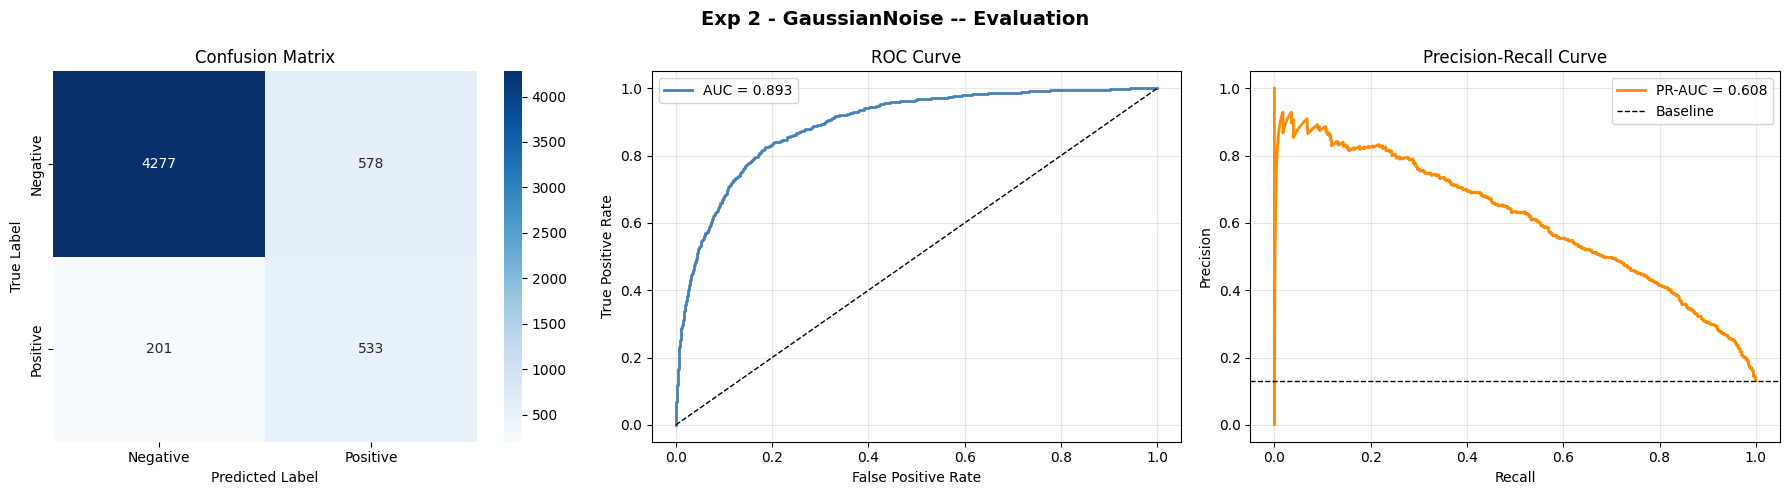

Evaluation plot saved


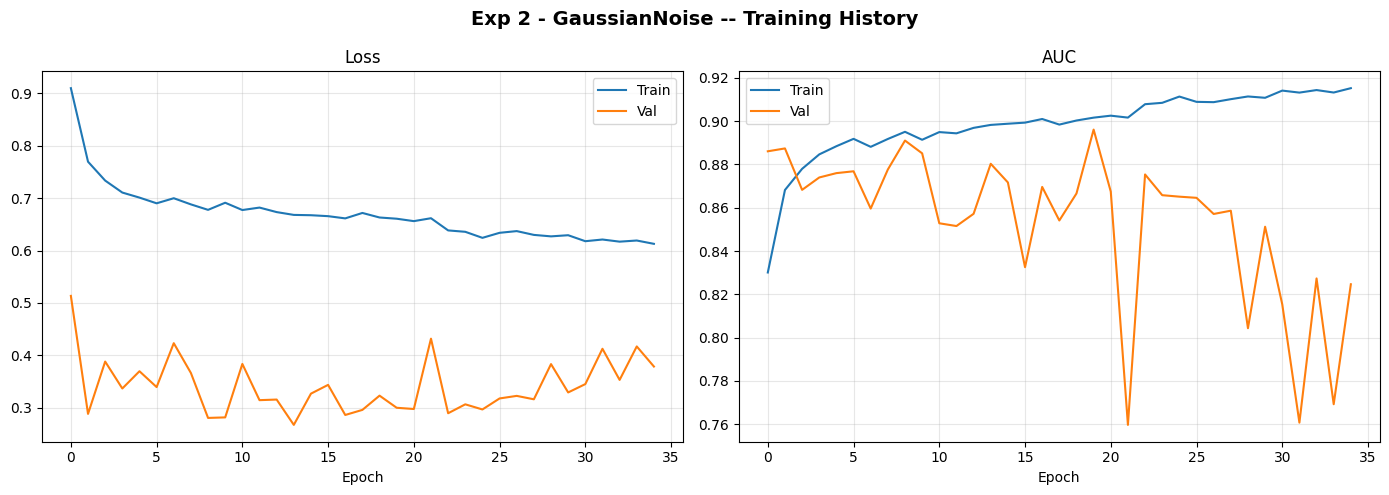

History plot saved

EXP 2 - GAUSSIANNOISE SUMMARY
Accuracy:                0.861
ROC-AUC:                 0.893
Sensitivity (Positive):  0.726
Specificity (Negative):  0.881

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963
Exp 1 - Dropout + SpatialDropout2D: Acc=0.841 | AUC=0.906 | Sens=0.793 | Spec=0.849
Exp 2 - GaussianNoise: Acc=0.861 | AUC=0.893 | Sens=0.726 | Spec=0.881


In [17]:
results = evaluate_experiment('Exp 2 - GaussianNoise Balanced',
    f'{SAVE_PATH}/exp2_best.keras', history_2,
    test_dataset, SAVE_PATH, results)

## Experiment 3 — Larger Network (3 Conv Blocks) + Skip Connection

Adds a third conv block (128 filters) and introduces a skip connection from
the output of block 3 via GlobalAveragePooling2D concatenated with the dense path.
Skip connections preserve spatial information that deep stacking can lose.

In [18]:
def build_exp3():
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.GaussianNoise(0.02)(inputs)
    x = layers.Conv2D(32,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    # Skip connection — global average pool from block 3
    skip = layers.GlobalAveragePooling2D()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='experiment_3_skip')

model_3 = build_exp3()
model_3.summary()

model_3.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp3_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=20,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-7, verbose=1
)

history_3 = model_3.fit(
    train_dataset,
    epochs=150,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_3, f'{SAVE_PATH}/exp3_end.keras')
import gc
del model_3
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared — ready for Exp 4")
print('Experiment 3 done')

Model: "experiment_3_skip"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ gaussian_noise[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 100352)    │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100480)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │  6,430,784 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]   

 Total params: 6,525,249 (24.89 MB)

 Trainable params: 6,524,673 (24.89 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/150
   1398/Unknown 131s 88ms/step - accuracy: 0.6755 - auc: 0.8211 - loss: 0.9860 - precision: 0.2638 - recall: 0.8325

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_auc improved from -inf to 0.88601, saving model to /kaggle/working/exp3_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 144s 97ms/step - accuracy: 0.6755 - auc: 0.8211 - loss: 0.9860 - precision: 0.2638 - recall: 0.8325 - val_accuracy: 0.8835 - val_auc: 0.8860 - val_loss: 0.2635 - val_precision: 0.5394 - val_recall: 0.5690 - learning_rate: 1.0000e-04
Epoch 2/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7619 - auc: 0.8630 - loss: 0.7958 - precision: 0.3322 - recall: 0.8260
Epoch 2: val_auc did not improve from 0.88601
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 136s 97ms/step - accuracy: 0.7619 - auc: 0.8630 - loss: 0.7958 - precision: 0.3322 - recall: 0.8260 - val_accuracy: 0.8388 - val_auc: 0.8345 - val_loss: 1.2280 - val_precision: 0.3983 - val_recall: 0.5268 - learning_rate: 1.0000e-04
Epoch 3/150
1396/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7992 - auc: 0.8816 - loss: 0.7217 - precision: 0.3746 - recall: 0.8194
Epoch 3: val_auc improved from 0.88601 to 0.894


Loading /kaggle/working/exp3_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([5315,  274]))

EXP 3 - LARGER NETWORK SKIP CONNECTION -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.90      0.99      0.94      4855
    Positive       0.78      0.29      0.42       734

    accuracy                           0.90      5589
   macro avg       0.84      0.64      0.68      5589
weighted avg       0.89      0.90      0.87      5589



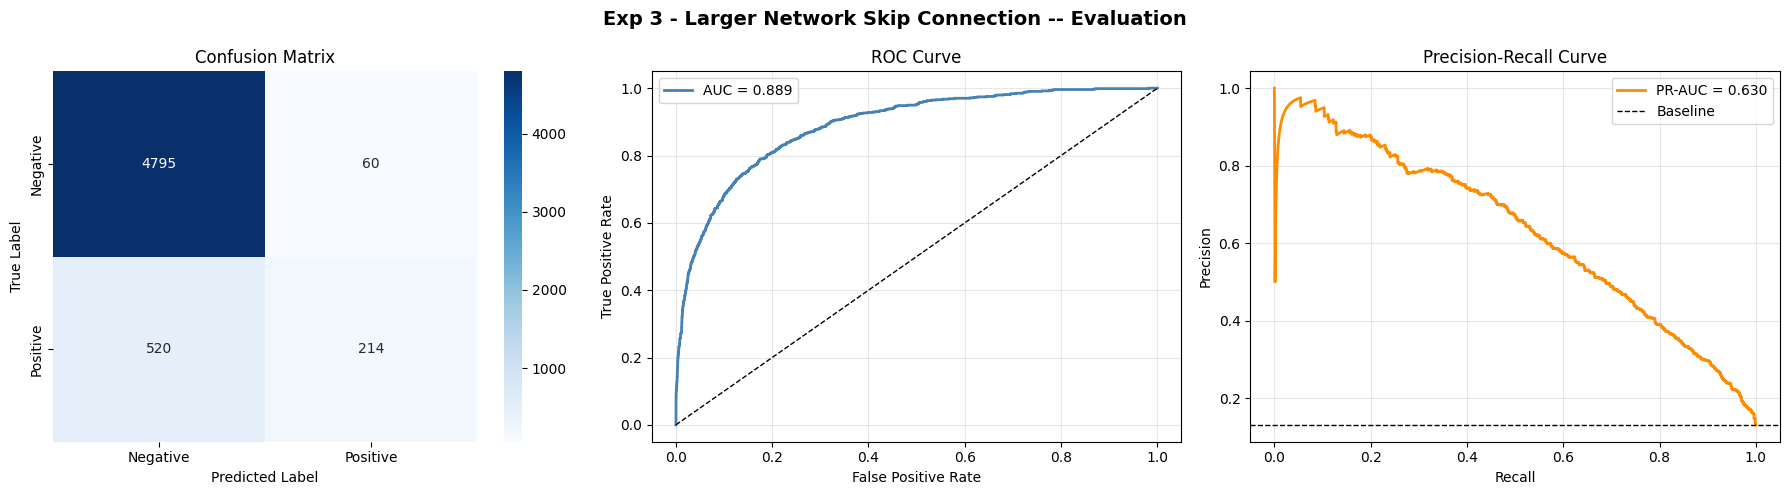

Evaluation plot saved


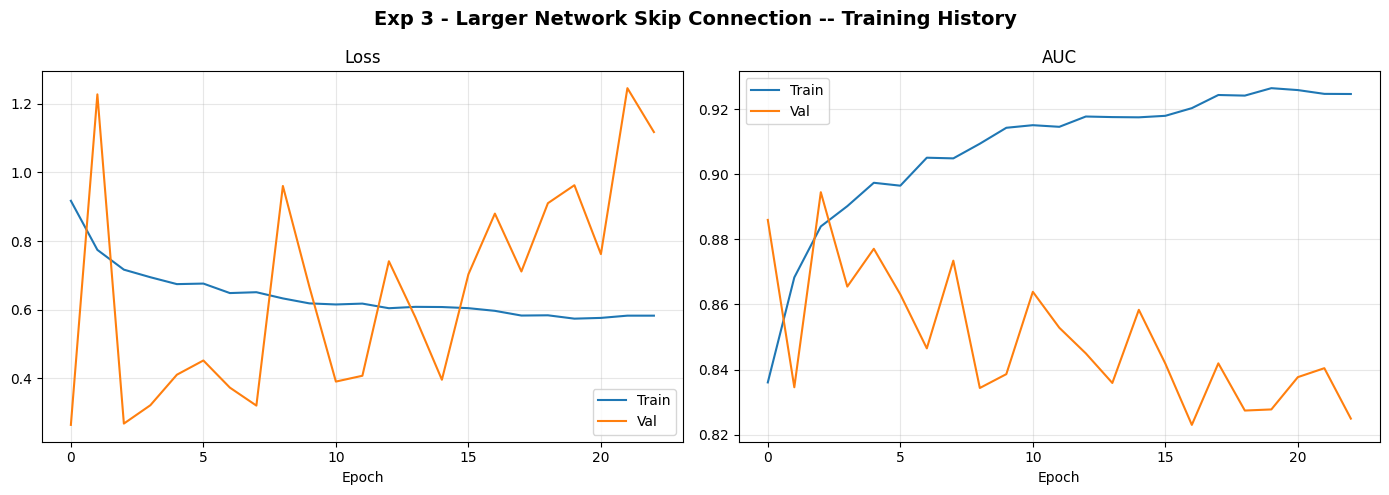

History plot saved

EXP 3 - LARGER NETWORK SKIP CONNECTION SUMMARY
Accuracy:                0.896
ROC-AUC:                 0.889
Sensitivity (Positive):  0.292
Specificity (Negative):  0.988

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963
Exp 1 - Dropout + SpatialDropout2D: Acc=0.841 | AUC=0.906 | Sens=0.793 | Spec=0.849
Exp 2 - GaussianNoise: Acc=0.861 | AUC=0.893 | Sens=0.726 | Spec=0.881
Exp 3 - Larger Network Skip Connection: Acc=0.896 | AUC=0.889 | Sens=0.292 | Spec=0.988


In [19]:
results = evaluate_experiment('Exp 3 - Larger Network Skip Connection',
    f'{SAVE_PATH}/exp3_best.keras', history_3,
    test_dataset, SAVE_PATH, results)

## Experiment 4 — Larger FC Layer + Dual Parallel Dense Paths

Increases the dense layer to 128 neurons and splits into two parallel dense
branches (48 neurons each) before the final sigmoid. Parallel paths allow the
model to learn different feature representations simultaneously.

In [23]:
def build_exp4():
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.GaussianNoise(0.02)(inputs)
    x = layers.Conv2D(32,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    # Dual parallel dense paths
    path_a = layers.Dense(48, activation='relu')(x)
    path_b = layers.Dense(48, activation='relu')(x)
    x = layers.Concatenate()([path_a, path_b])
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='experiment_4_dual_dense')

model_4 = build_exp4()
model_4.summary()

model_4.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp4_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=15,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-7, verbose=1
)

history_4 = model_4.fit(
    train_dataset,
    epochs=150,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_4, f'{SAVE_PATH}/exp4_end.keras')
import gc
del model_4
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared — ready for Exp 5")
print('Experiment 4 done')

Model: "experiment_4_dual_dense"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (GaussianNoise)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │        896 │ gaussian_noise_1… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 100352)    │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │ 12,845,184 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 48)        │      6,192 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 48)        │      6,192 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 12,952,705 (49.41 MB)

 Trainable params: 12,951,809 (49.41 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/150
   1398/Unknown 130s 87ms/step - accuracy: 0.6873 - auc: 0.8331 - loss: 0.8856 - precision: 0.2768 - recall: 0.8515
Epoch 1: val_auc improved from -inf to 0.88768, saving model to /kaggle/working/exp4_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.6873 - auc: 0.8331 - loss: 0.8855 - precision: 0.2768 - recall: 0.8515 - val_accuracy: 0.8193 - val_auc: 0.8877 - val_loss: 0.3911 - val_precision: 0.3930 - val_recall: 0.7761 - learning_rate: 1.0000e-04
Epoch 2/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7985 - auc: 0.8846 - loss: 0.7098 - precision: 0.3756 - recall: 0.8294
Epoch 2: val_auc did not improve from 0.88768
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 130s 92ms/step - accuracy: 0.7985 - auc: 0.8846 - loss: 0.7098 - precision: 0.3757 - recall: 0.8294 - val_accuracy: 0.8559 - val_auc: 0.8482 - val_loss: 0.4144 - val_precision: 0.4514 - val_recall: 0.6211 - learning_rate: 1.0000e-04
Epoch 3/150
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc


Loading /kaggle/working/exp4_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([5136,  453]))

EXP 4 - DUAL PARALLEL DENSE PATHS -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.91      0.96      0.94      4855
    Positive       0.61      0.38      0.47       734

    accuracy                           0.89      5589
   macro avg       0.76      0.67      0.70      5589
weighted avg       0.87      0.89      0.87      5589



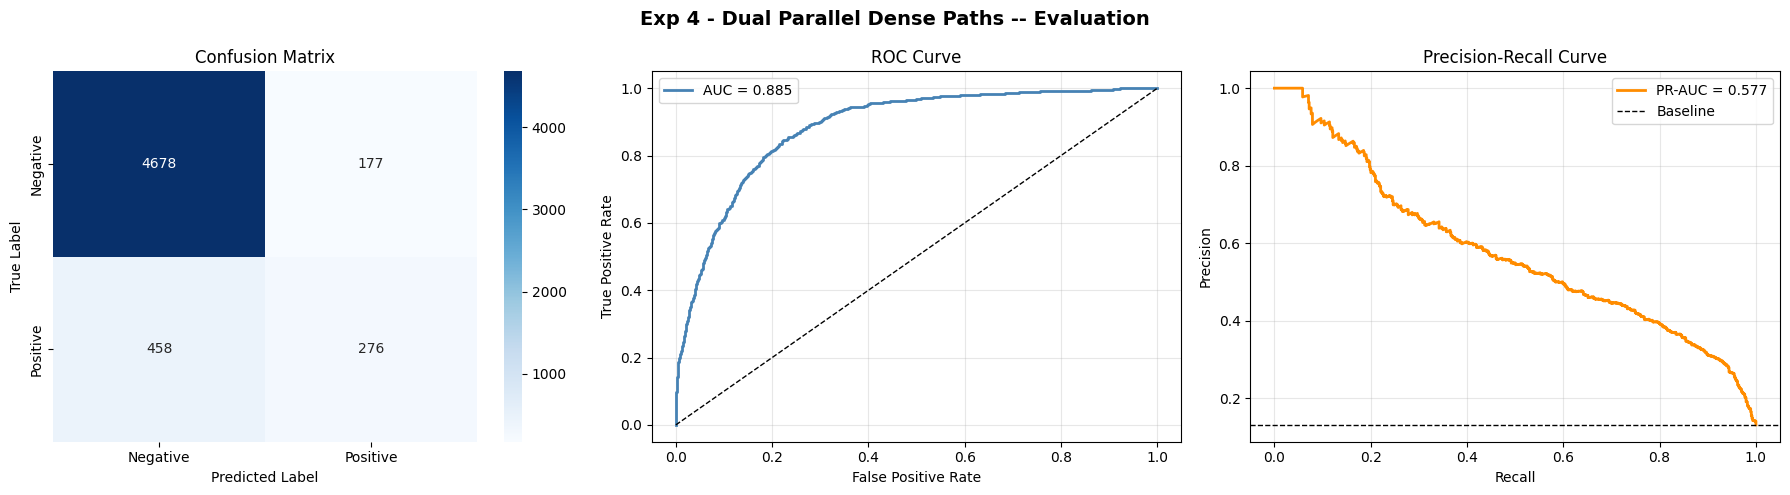

Evaluation plot saved


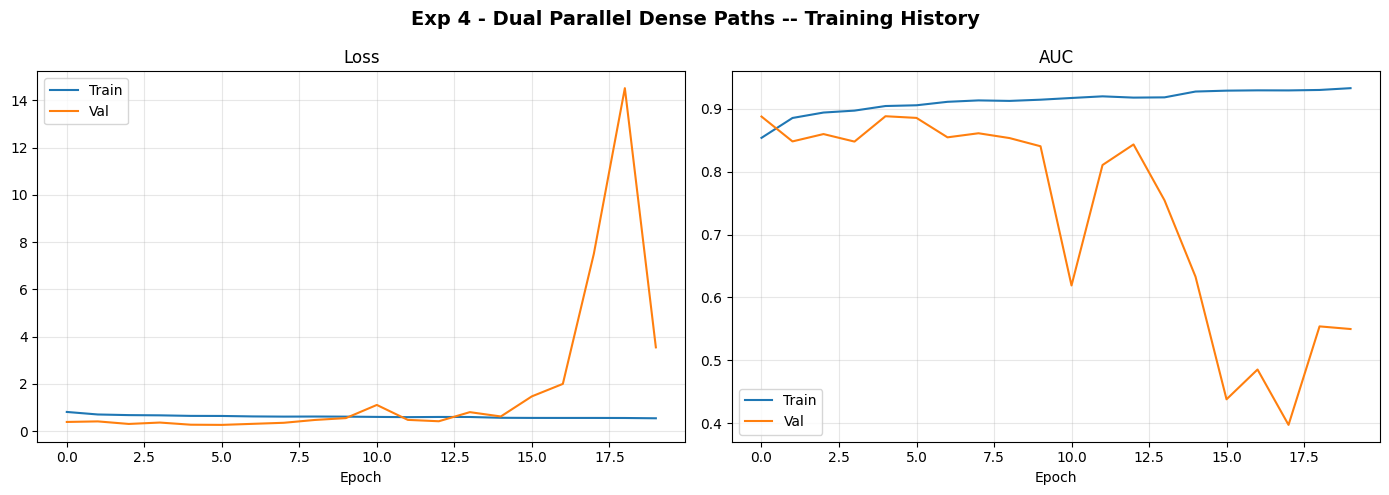

History plot saved

EXP 4 - DUAL PARALLEL DENSE PATHS SUMMARY
Accuracy:                0.886
ROC-AUC:                 0.885
Sensitivity (Positive):  0.376
Specificity (Negative):  0.964

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963
Exp 1 - Dropout + SpatialDropout2D: Acc=0.841 | AUC=0.906 | Sens=0.793 | Spec=0.849
Exp 2 - GaussianNoise: Acc=0.861 | AUC=0.893 | Sens=0.726 | Spec=0.881
Exp 3 - Larger Network Skip Connection: Acc=0.896 | AUC=0.889 | Sens=0.292 | Spec=0.988
Exp 4 - Dual Parallel Dense Paths: Acc=0.886 | AUC=0.885 | Sens=0.376 | Spec=0.964


In [24]:
results = evaluate_experiment('Exp 4 - Dual Parallel Dense Paths',
    f'{SAVE_PATH}/exp4_best.keras', history_4,
    test_dataset, SAVE_PATH, results)

## Experiment 5 — Cosine Annealing Learning Rate Schedule

Replaces ReduceLROnPlateau with a cosine annealing schedule. Cosine annealing
periodically reduces and partially restores the learning rate, helping the model
escape local minima that a monotonically decreasing schedule can get stuck in.

In [25]:
def build_exp5():
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.GaussianNoise(0.02)(inputs)
    x = layers.Conv2D(32,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='experiment_5_cosine_lr')

model_5 = build_exp5()
model_5.summary()

# Cosine annealing schedule
cosine_lr = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=500,
    t_mul=2.0,
    m_mul=0.9
)

model_5.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=cosine_lr),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp5_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=20,
    restore_best_weights=True, verbose=1
)

history_5 = model_5.fit(
    train_dataset,
    epochs=150,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_5, f'{SAVE_PATH}/exp5_end.keras')
import gc
del model_5
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared — ready for Exp 6")
print('Experiment 5 done')

Model: "experiment_5_cosine_lr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,969 (49.36 MB)

 Trainable params: 12,939,265 (49.36 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/150
   1398/Unknown 131s 88ms/step - accuracy: 0.6594 - auc: 0.8094 - loss: 1.0280 - precision: 0.2541 - recall: 0.8303

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_auc improved from -inf to 0.88558, saving model to /kaggle/working/exp5_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.6594 - auc: 0.8094 - loss: 1.0279 - precision: 0.2541 - recall: 0.8303 - val_accuracy: 0.8880 - val_auc: 0.8856 - val_loss: 0.2677 - val_precision: 0.5652 - val_recall: 0.5127
Epoch 2/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7395 - auc: 0.8552 - loss: 0.8401 - precision: 0.3105 - recall: 0.8355
Epoch 2: val_auc did not improve from 0.88558
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 128s 92ms/step - accuracy: 0.7395 - auc: 0.8552 - loss: 0.8401 - precision: 0.3105 - recall: 0.8355 - val_accuracy: 0.8899 - val_auc: 0.8780 - val_loss: 0.2900 - val_precision: 0.5835 - val_recall: 0.4676
Epoch 3/150
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7722 - auc: 0.8780 - loss: 0.7526 - precision: 0.3440 - recall: 0.8351
Epoch 3: val_auc did not improve from 0.88558
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 128s 91ms/step - accuracy:


Loading /kaggle/working/exp5_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([4871,  718]))

EXP 5 - COSINE ANNEALING LR -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.93      0.93      0.93      4855
    Positive       0.56      0.54      0.55       734

    accuracy                           0.88      5589
   macro avg       0.74      0.74      0.74      5589
weighted avg       0.88      0.88      0.88      5589



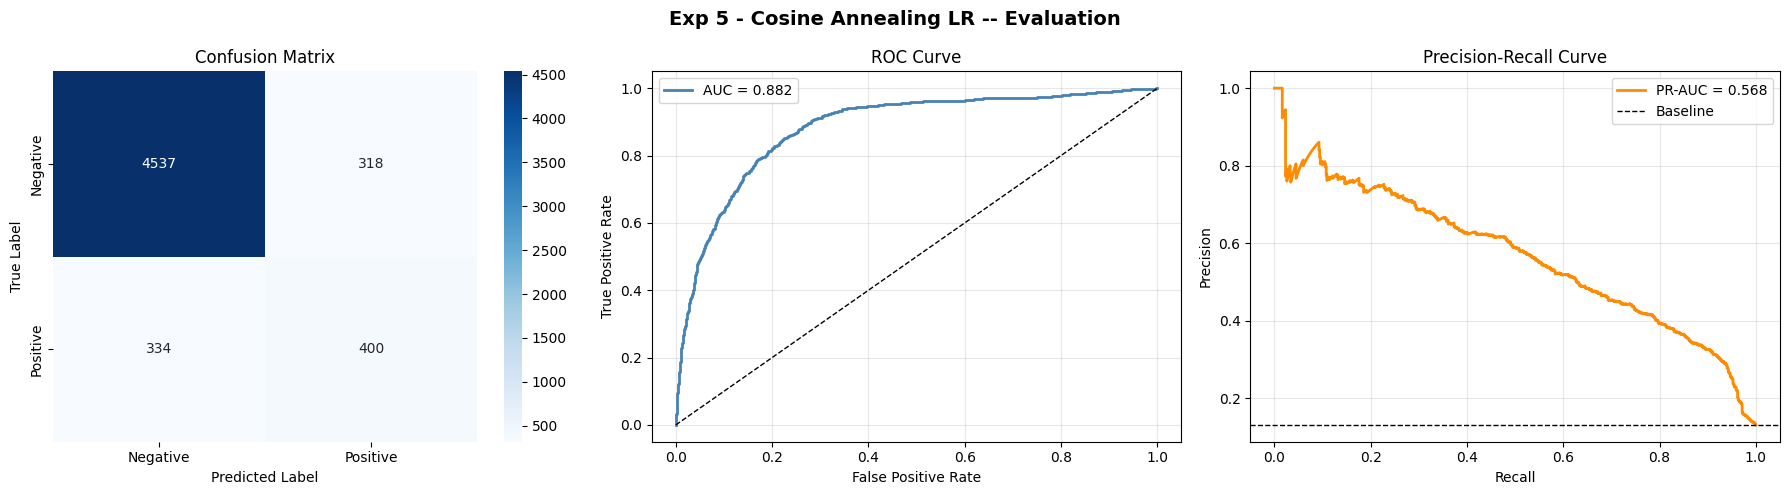

Evaluation plot saved


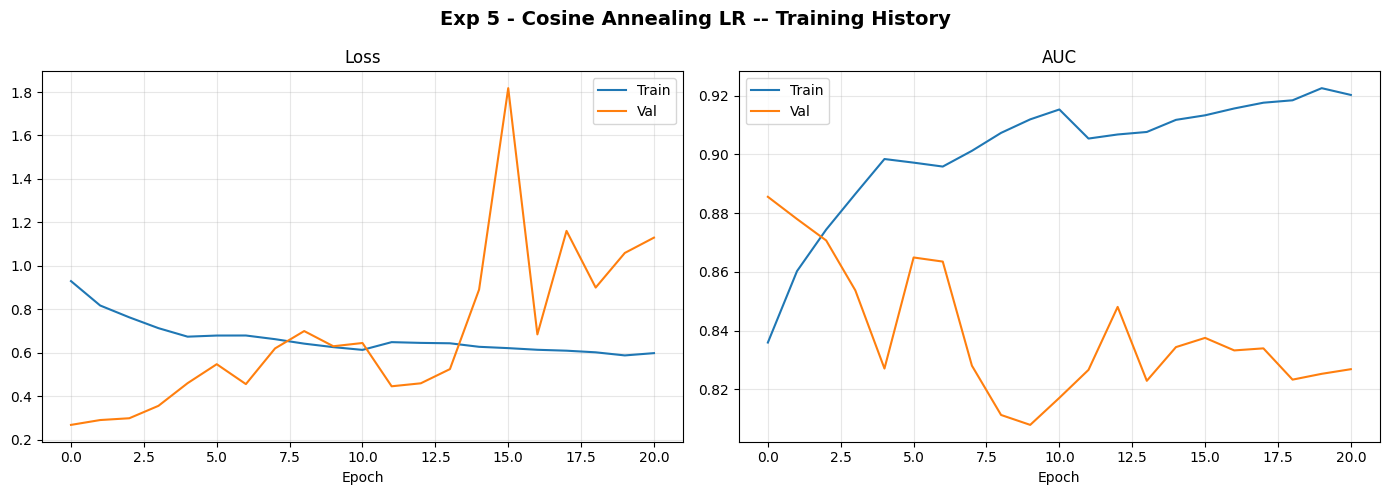

History plot saved

EXP 5 - COSINE ANNEALING LR SUMMARY
Accuracy:                0.883
ROC-AUC:                 0.882
Sensitivity (Positive):  0.545
Specificity (Negative):  0.935

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963
Exp 1 - Dropout + SpatialDropout2D: Acc=0.841 | AUC=0.906 | Sens=0.793 | Spec=0.849
Exp 2 - GaussianNoise: Acc=0.861 | AUC=0.893 | Sens=0.726 | Spec=0.881
Exp 3 - Larger Network Skip Connection: Acc=0.896 | AUC=0.889 | Sens=0.292 | Spec=0.988
Exp 4 - Dual Parallel Dense Paths: Acc=0.886 | AUC=0.885 | Sens=0.376 | Spec=0.964
Exp 5 - Cosine Annealing LR: Acc=0.883 | AUC=0.882 | Sens=0.545 | Spec=0.935


In [28]:
results = evaluate_experiment('Exp 5 - Cosine Annealing LR',
    f'{SAVE_PATH}/exp5_best.keras', history_5,
    test_dataset, SAVE_PATH, results)

## Experiment 6 — Deeper Network (4 Conv Blocks) + Pyramid Pooling

Adds a fourth conv block (256 filters) and uses pyramid pooling — combining
GlobalAveragePooling2D (captures global context) with MaxPooling2D + Flatten
(captures local detail) — before the dense layers.

In [26]:
def build_exp6():
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.GaussianNoise(0.02)(inputs)
    x = layers.Conv2D(32,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    # Pyramid pooling — global + local
    pool_global = layers.GlobalAveragePooling2D()(x)
    pool_local  = layers.MaxPooling2D((2, 2))(x)
    pool_local  = layers.Flatten()(pool_local)
    x = layers.Concatenate()([pool_global, pool_local])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='experiment_6_pyramid')

model_6 = build_exp6()
model_6.summary()

model_6.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp6_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=20,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-7, verbose=1
)

history_6 = model_6.fit(
    train_dataset,
    epochs=150,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_6, f'{SAVE_PATH}/exp6_end.keras')
import gc
del model_6
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared — ready for Exp 6b")
print('Experiment 6 done')

Model: "experiment_6_pyramid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ gaussian_noise[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50176)     │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 50432)     │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ flatten[0][0]   

 Total params: 6,846,401 (26.12 MB)

 Trainable params: 6,845,185 (26.11 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/150
   1398/Unknown 135s 90ms/step - accuracy: 0.6660 - auc: 0.8171 - loss: 1.0048 - precision: 0.2588 - recall: 0.8324
Epoch 1: val_auc improved from -inf to 0.87893, saving model to /kaggle/working/exp6_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 147s 99ms/step - accuracy: 0.6660 - auc: 0.8171 - loss: 1.0047 - precision: 0.2588 - recall: 0.8324 - val_accuracy: 0.8853 - val_auc: 0.8789 - val_loss: 0.3022 - val_precision: 0.8632 - val_recall: 0.1155 - learning_rate: 1.0000e-04
Epoch 2/150
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7723 - auc: 0.8781 - loss: 0.7482 - precision: 0.3456 - recall: 0.8361
Epoch 2: val_auc improved from 0.87893 to 0.90024, saving model to /kaggle/working/exp6_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 131s 93ms/step - accuracy: 0.7723 - auc: 0.8781 - loss: 0.7482 - precision: 0.3456 - recall: 0.8361 - val_accuracy: 0.7629 - val_auc: 0.9002 - val_loss: 0.4823 - val_precision: 0.3328 - val_recall: 0.8620 - learning_rate: 1.0000e-04
Epoch 3/


Loading /kaggle/working/exp6_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([3696, 1893]))

EXP 6 - DEEPER PYRAMID POOLING -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.97      0.74      0.84      4855
    Positive       0.33      0.86      0.48       734

    accuracy                           0.76      5589
   macro avg       0.65      0.80      0.66      5589
weighted avg       0.89      0.76      0.79      5589



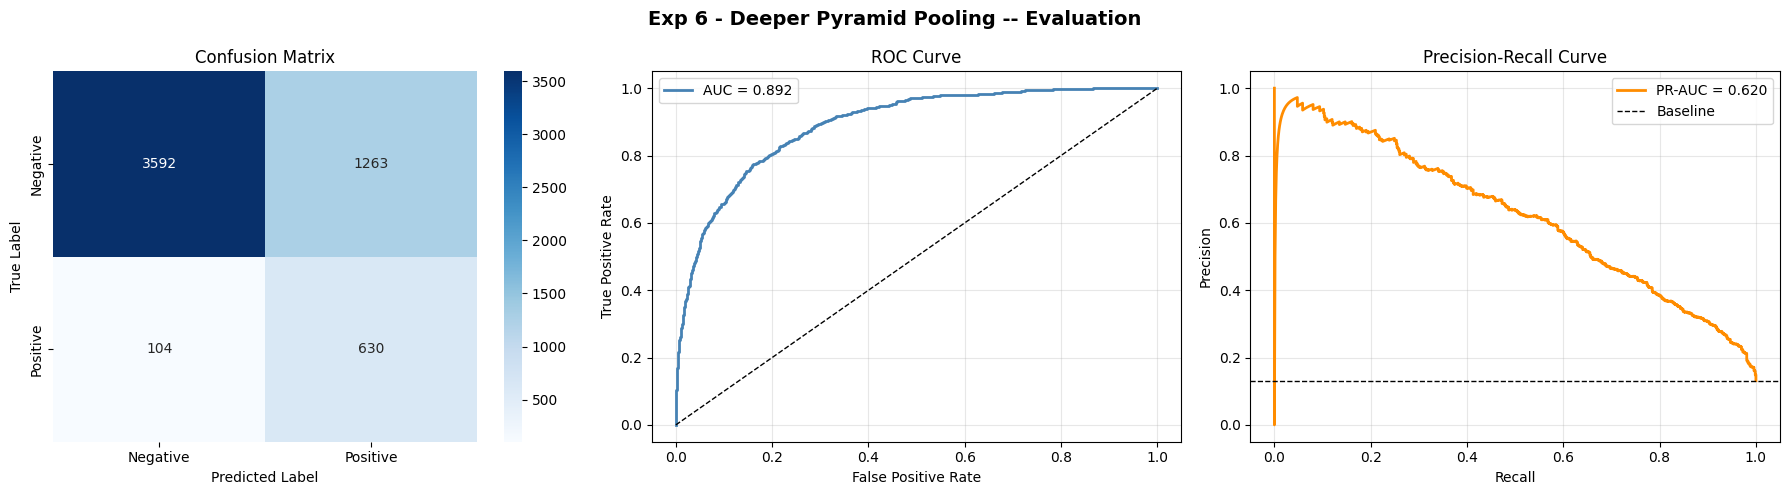

Evaluation plot saved


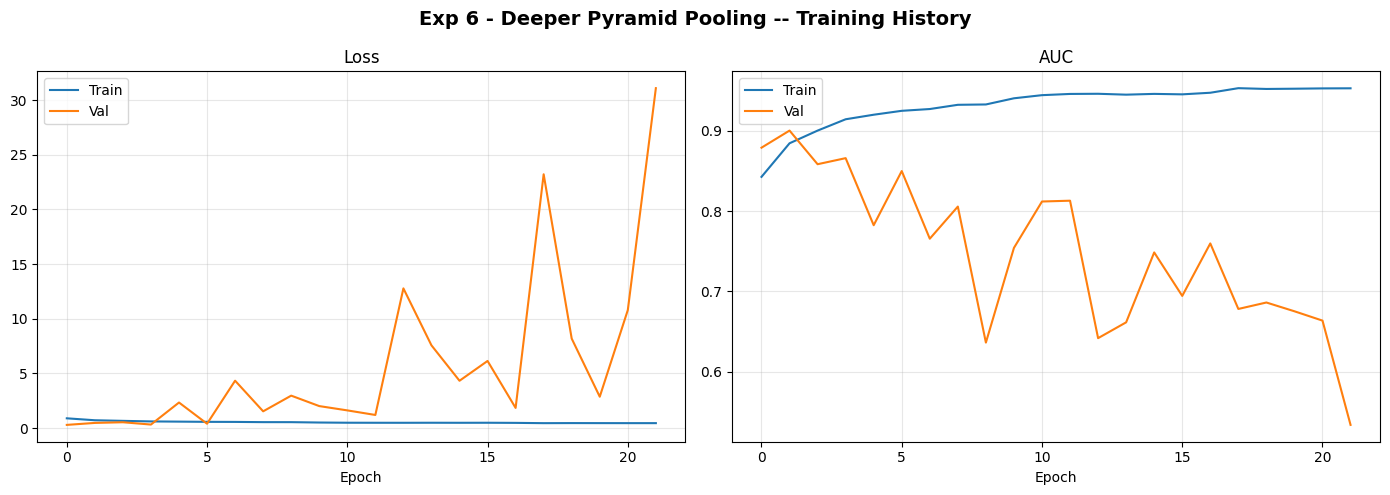

History plot saved

EXP 6 - DEEPER PYRAMID POOLING SUMMARY
Accuracy:                0.755
ROC-AUC:                 0.892
Sensitivity (Positive):  0.858
Specificity (Negative):  0.740

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963
Exp 1 - Dropout + SpatialDropout2D: Acc=0.841 | AUC=0.906 | Sens=0.793 | Spec=0.849
Exp 2 - GaussianNoise: Acc=0.861 | AUC=0.893 | Sens=0.726 | Spec=0.881
Exp 3 - Larger Network Skip Connection: Acc=0.896 | AUC=0.889 | Sens=0.292 | Spec=0.988
Exp 4 - Dual Parallel Dense Paths: Acc=0.886 | AUC=0.885 | Sens=0.376 | Spec=0.964
Exp 5 - Cosine Annealing LR: Acc=0.883 | AUC=0.882 | Sens=0.545 | Spec=0.935
Exp 6 - Deeper Pyramid Pooling: Acc=0.755 | AUC=0.892 | Sens=0.858 | Spec=0.74


In [29]:
results = evaluate_experiment('Exp 6 - Deeper Pyramid Pooling',
    f'{SAVE_PATH}/exp6_best.keras', history_6,
    test_dataset, SAVE_PATH, results)

## Experiment 7 — L2 Regularisation

L2 weight regularisation adds a penalty proportional to the sum of squared weights,
discouraging large weights and forcing learning to distribute across more neurons.

L2 (1e-4) is applied to all Conv2D and Dense layers. This is a conservative value —
augmentation, dropout, and BatchNormalization are already active, so L2 only needs
to provide a mild additional constraint. The architecture builds on Exp 6b with L2
added throughout and extended training retained.

In [ ]:
def build_exp7():
    reg = tf.keras.regularizers.l2(1e-4)
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.GaussianNoise(0.02)(inputs)
    x = layers.Conv2D(32,  (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    pool_global = layers.GlobalAveragePooling2D()(x)
    pool_local  = layers.MaxPooling2D((2, 2))(x)
    pool_local  = layers.Flatten()(pool_local)
    x = layers.Concatenate()([pool_global, pool_local])
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='experiment_7_l2')

model_7 = build_exp7()
model_7.summary()

model_7.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}/exp7_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_auc', patience=40,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=10, min_lr=1e-7, verbose=1
)

history_7 = model_7.fit(
    train_dataset,
    epochs=200,
    validation_data=val_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_7, f'{SAVE_PATH}/exp7_end.keras')
import gc
del model_7
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared")
print('Experiment 7 done')

Model: "experiment_7_l2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ gaussian_noise[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50176)     │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 50432)     │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ flatten[0][0]   

 Total params: 6,846,401 (26.12 MB)

 Trainable params: 6,845,185 (26.11 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/200
   1398/Unknown 130s 87ms/step - accuracy: 0.6768 - auc: 0.8217 - loss: 1.0156 - precision: 0.2669 - recall: 0.8299
Epoch 1: val_auc improved from -inf to 0.89794, saving model to /kaggle/working/exp7_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 142s 95ms/step - accuracy: 0.6768 - auc: 0.8217 - loss: 1.0156 - precision: 0.2669 - recall: 0.8299 - val_accuracy: 0.8615 - val_auc: 0.8979 - val_loss: 0.3694 - val_precision: 0.4712 - val_recall: 0.7380 - learning_rate: 1.0000e-04
Epoch 2/200
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7897 - auc: 0.8845 - loss: 0.7818 - precision: 0.3638 - recall: 0.8289
Epoch 2: val_auc did not improve from 0.89794
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 124s 88ms/step - accuracy: 0.7898 - auc: 0.8845 - loss: 0.7817 - precision: 0.3638 - recall: 0.8289 - val_accuracy: 0.7165 - val_auc: 0.8399 - val_loss: 0.5910 - val_precision: 0.2832 - val_recall: 0.8042 - learning_rate: 1.0000e-04
Epoch 3/200
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc


Loading /kaggle/working/exp7_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([4437, 1152]))

EXP 7 - L2 REGULARISATION -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.95      0.87      0.91      4855
    Positive       0.45      0.70      0.55       734

    accuracy                           0.85      5589
   macro avg       0.70      0.78      0.73      5589
weighted avg       0.88      0.85      0.86      5589



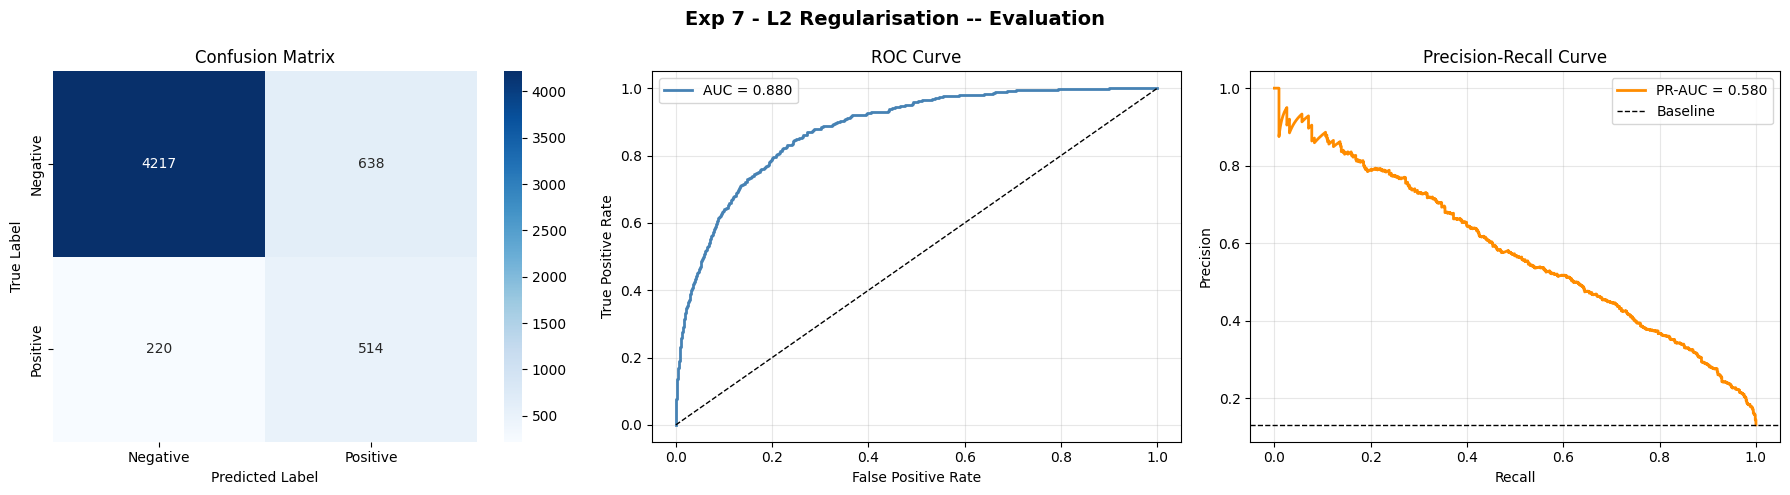

Evaluation plot saved


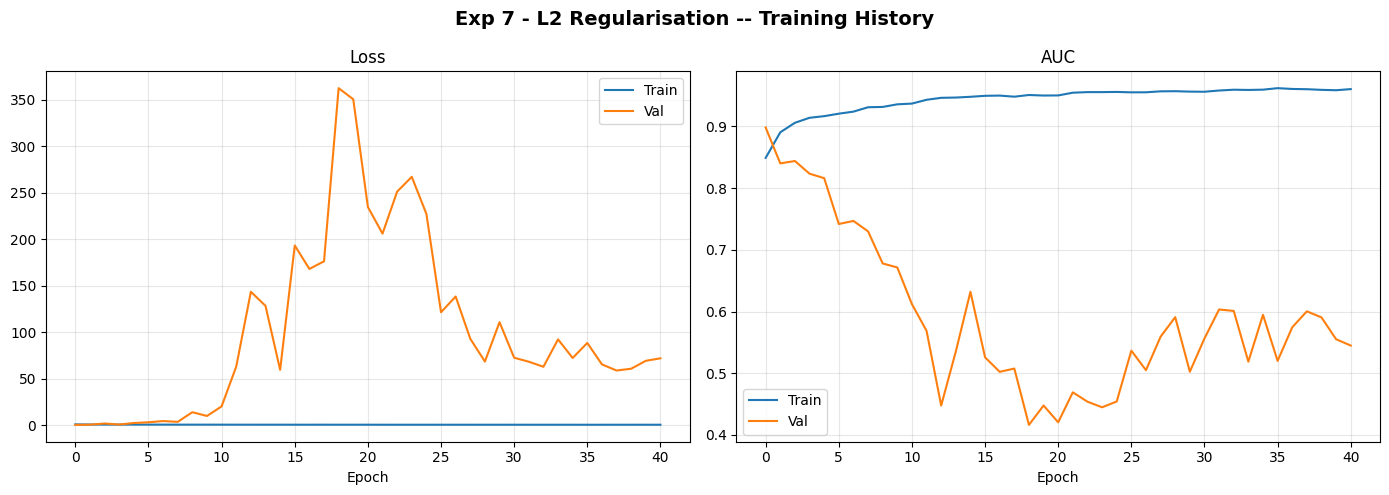

History plot saved

EXP 7 - L2 REGULARISATION SUMMARY
Accuracy:                0.846
ROC-AUC:                 0.880
Sensitivity (Positive):  0.700
Specificity (Negative):  0.869

RESULTS TRACKER
Exp 0 - Baseline CNN: Acc=0.907 | AUC=0.904 | Sens=0.534 | Spec=0.963
Exp 1 - Dropout + SpatialDropout2D: Acc=0.841 | AUC=0.906 | Sens=0.793 | Spec=0.849
Exp 2 - GaussianNoise: Acc=0.861 | AUC=0.893 | Sens=0.726 | Spec=0.881
Exp 3 - Larger Network Skip Connection: Acc=0.896 | AUC=0.889 | Sens=0.292 | Spec=0.988
Exp 4 - Dual Parallel Dense Paths: Acc=0.886 | AUC=0.885 | Sens=0.376 | Spec=0.964
Exp 5 - Cosine Annealing LR: Acc=0.883 | AUC=0.882 | Sens=0.545 | Spec=0.935
Exp 6 - Deeper Pyramid Pooling: Acc=0.755 | AUC=0.892 | Sens=0.858 | Spec=0.74
Exp 7 - L2 Regularisation: Acc=0.846 | AUC=0.88 | Sens=0.7 | Spec=0.869


In [32]:
results = evaluate_experiment('Exp 7 - L2 Regularisation',
    f'{SAVE_PATH}/exp7_best.keras', history_7,
    test_dataset, SAVE_PATH, results)

## Final Results Comparison

All experiments are compared across accuracy, AUC, sensitivity, and specificity.
Sensitivity measures how well the model detects positive cases — the most clinically
important metric. The bar chart highlights the best performing model in each metric
with a red border.


FINAL RESULTS TABLE
                                        accuracy  roc_auc  sensitivity  specificity
Experiment                                                                         
Exp 0 - Baseline CNN                       0.907    0.904        0.534        0.963
Exp 1 - Dropout + SpatialDropout2D         0.841    0.906        0.793        0.849
Exp 2 - GaussianNoise                      0.861    0.893        0.726        0.881
Exp 3 - Larger Network Skip Connection     0.896    0.889        0.292        0.988
Exp 4 - Dual Parallel Dense Paths          0.886    0.885        0.376        0.964
Exp 5 - Cosine Annealing LR                0.883    0.882        0.545        0.935
Exp 6 - Deeper Pyramid Pooling             0.755    0.892        0.858        0.740
Exp 7 - L2 Regularisation                  0.846    0.880        0.700        0.869


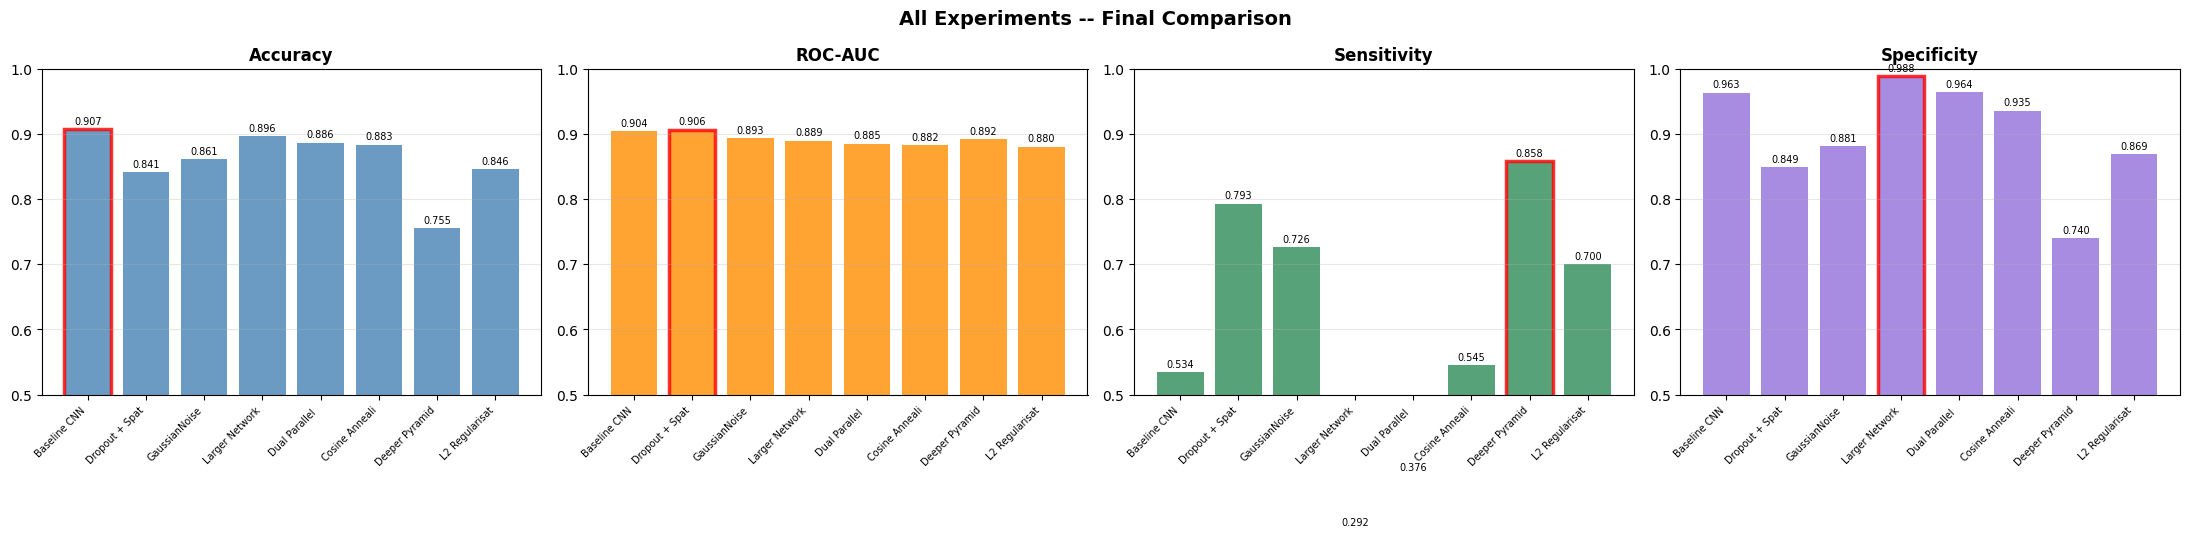

Final comparison saved


In [33]:
df = pd.DataFrame(results).T
df.index.name = 'Experiment'
print('\nFINAL RESULTS TABLE')
print('='*70)
print(df.to_string())

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('All Experiments -- Final Comparison', fontsize=14, fontweight='bold')

metrics   = ['accuracy', 'roc_auc', 'sensitivity', 'specificity']
titles    = ['Accuracy', 'ROC-AUC', 'Sensitivity', 'Specificity']
colours   = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
exp_names = [e.split(' - ')[-1][:14] for e in results.keys()]

for ax, metric, title, colour in zip(axes, metrics, titles, colours):
    values = [results[exp][metric] for exp in results]
    bars   = ax.bar(range(len(values)), values, color=colour, alpha=0.8)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(exp_names, fontsize=7, rotation=45, ha='right')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis='y', alpha=0.3)
    best_idx = values.index(max(values))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final comparison saved')